# STAT 656 Final Project

## Setup and Data Load


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

sns.set(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)

data_path = Path("AirQualityUCI.csv")

## Read CSV (UCI file uses semicolons and comma as decimal; -200 marks missing)


In [2]:
df_raw = pd.read_csv(
    data_path,
    sep=";",
    decimal=",",
    na_values=[-200],
    engine="python"
)

## Drop completely empty columns (the file often has a trailing blank column)


In [3]:
df_raw = df_raw.dropna(axis=1, how="all")

print("Shape (raw):", df_raw.shape)
df_raw.head()

Shape (raw): (9471, 15)


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


## Basic Cleaning & Time Features


### Combine Date and Time into a single datetime
### Date format is 'DD/MM/YYYY' and Time 'HH.MM.SS'

In [4]:
dt = pd.to_datetime(df_raw["Date"] + " " + df_raw["Time"], format="%d/%m/%Y %H.%M.%S", errors="coerce")
df = df_raw.copy()
df["datetime"] = dt
df = df.drop(columns=["Date", "Time"])
df = df.dropna(subset=["datetime"]).sort_values("datetime").reset_index(drop=True)

## Ensure numeric types for sensor columns


In [5]:
for c in df.columns:
    if c != "datetime":
        df[c] = pd.to_numeric(df[c], errors="coerce")

## Time-based features


In [7]:
df["hour"] = df["datetime"].dt.hour
df["dow"] = df["datetime"].dt.dayofweek  # 0=Mon
df["month"] = df["datetime"].dt.month

print("Shape (clean):", df.shape)
df.describe().T.head(10)

Shape (clean): (9357, 17)


,count,mean,min,25%,50%,75%,max,std
CO(GT),7674.0,2.15275,0.1,1.1,1.8,2.9,11.9,1.453252
PT08.S1(CO),8991.0,1099.833166,647.0,937.0,1063.0,1231.0,2040.0,217.080037
NMHC(GT),914.0,218.811816,7.0,67.0,150.0,297.0,1189.0,204.459921
C6H6(GT),8991.0,10.083105,0.1,4.4,8.2,14.0,63.7,7.44982
PT08.S2(NMHC),8991.0,939.153376,383.0,734.5,909.0,1116.0,2214.0,266.831429
NOx(GT),7718.0,246.896735,2.0,98.0,180.0,326.0,1479.0,212.979168
PT08.S3(NOx),8991.0,835.493605,322.0,658.0,806.0,969.5,2683.0,256.81732
NO2(GT),7715.0,113.091251,2.0,78.0,109.0,142.0,340.0,48.370108
PT08.S4(NO2),8991.0,1456.264598,551.0,1227.0,1463.0,1674.0,2775.0,346.206794
PT08.S5(O3),8991.0,1022.906128,221.0,731.5,963.0,1273.5,2523.0,398.484288


## Missing Values Overview


In [8]:
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
mv = pd.DataFrame({"missing": missing, "missing_pct": missing_pct})
mv[mv["missing"] > 0].head(20)

,missing,missing_pct
NMHC(GT),8443,90.23
CO(GT),1683,17.99
NO2(GT),1642,17.55
NOx(GT),1639,17.52
PT08.S5(O3),366,3.91
AH,366,3.91
RH,366,3.91
T,366,3.91
PT08.S4(NO2),366,3.91
PT08.S1(CO),366,3.91


## Time Series Overview (Selected Pollutants)

### Heuristic selection of pollutant columns present in the dataset

In [9]:
candidate_keys = ["CO", "NO2", "C6H6", "O3"]
pollutant_cols = [c for c in df.columns if c != "datetime" and any(k in c for k in candidate_keys)]

print("Selected pollutant columns:", pollutant_cols[:6])

Selected pollutant columns: ['CO(GT)', 'PT08.S1(CO)', 'C6H6(GT)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)']


## Plot first 3 pollutants over time


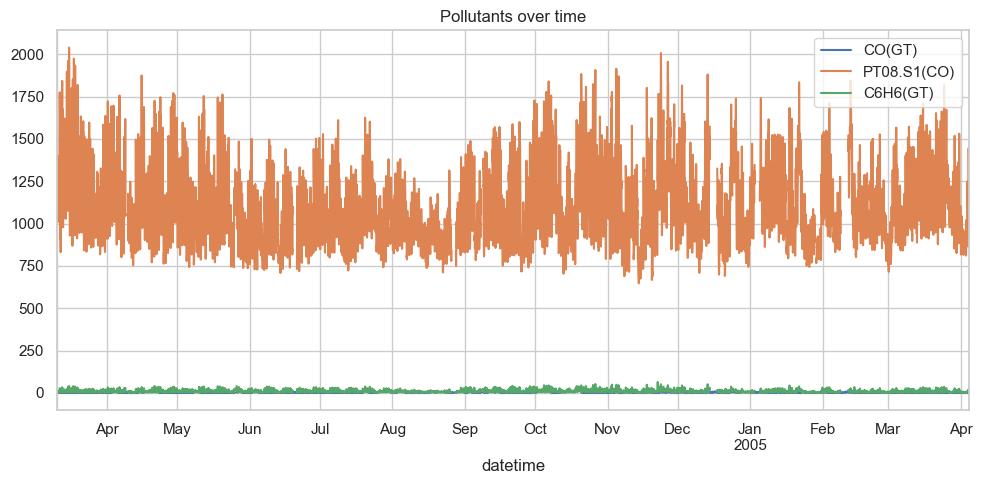

In [10]:
cols_to_plot = pollutant_cols[:3] if len(pollutant_cols) >= 3 else pollutant_cols
ax = None
for c in cols_to_plot:
    ax = df.plot(x="datetime", y=c, ax=ax, title="Pollutants over time")
plt.tight_layout()

## Distributions & Outliers


In [11]:
num_cols = [c for c in df.columns if c not in ["datetime"] and pd.api.types.is_numeric_dtype(df[c])]
sample_cols = num_cols[:6]


## Histograms

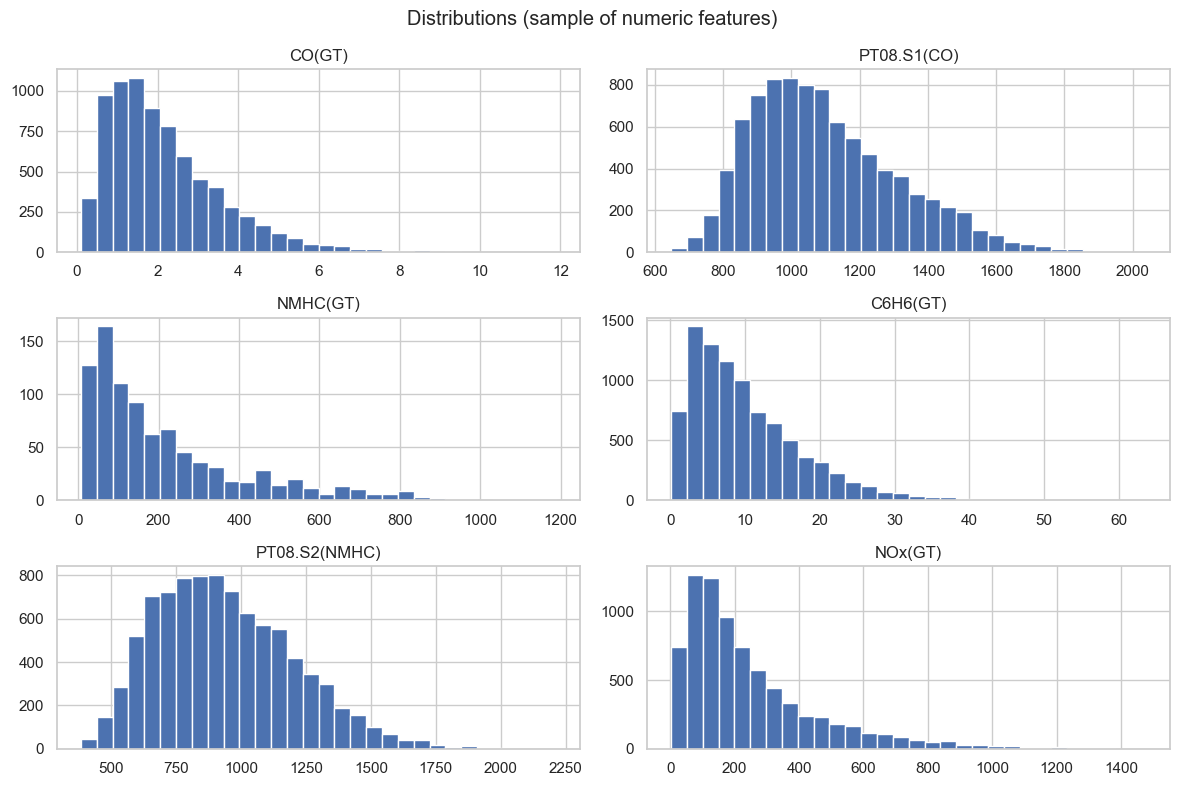

In [12]:
df[sample_cols].hist(bins=30, figsize=(12, 8))
plt.suptitle("Distributions (sample of numeric features)")
plt.tight_layout()

## Boxplots for the same sample


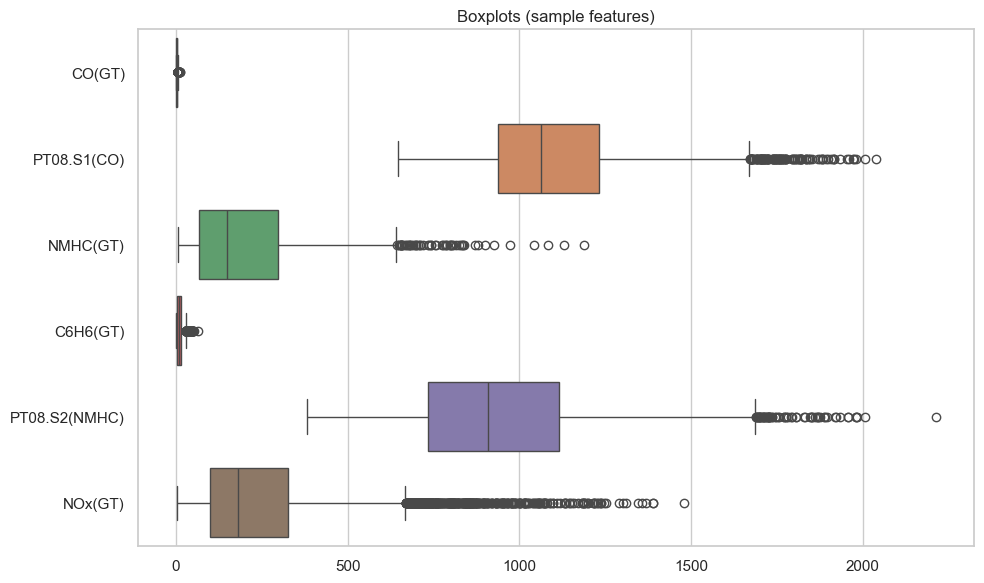

In [14]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[sample_cols], orient="h")
plt.title("Boxplots (sample features)")
plt.tight_layout()

## Correlations


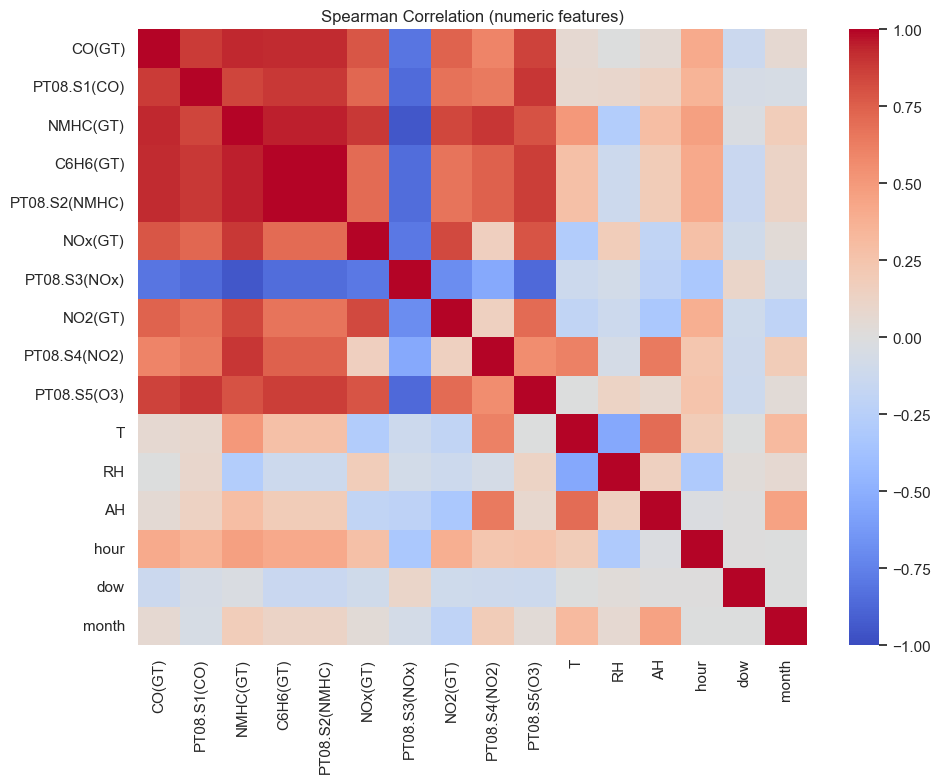

In [15]:
corr = df[num_cols].corr(method="spearman")
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Spearman Correlation (numeric features)")
plt.tight_layout()

## Relationships with Temperature/Humidity (if available)


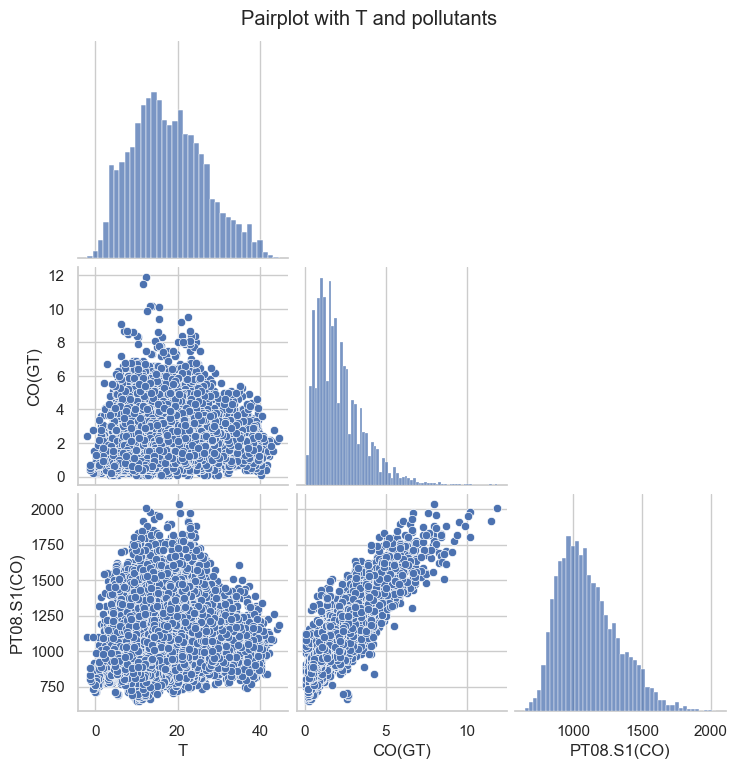

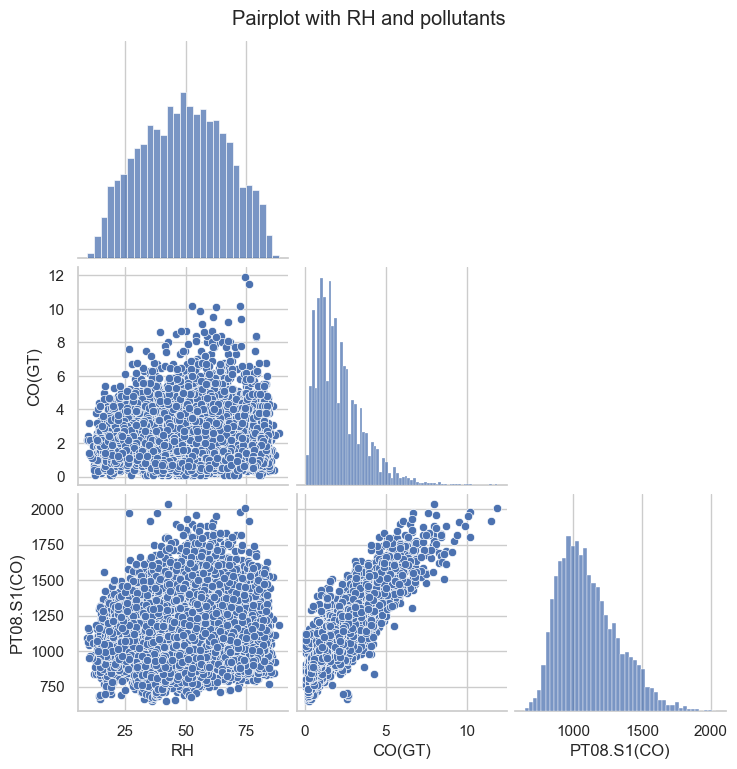

In [16]:
temp_col = next((c for c in df.columns if "T" == c or "Temp" in c or "Temperature" in c), None)
hum_col = next((c for c in df.columns if "RH" == c or "Humidity" in c), None)

targets = pollutant_cols[:2] if len(pollutant_cols) >= 2 else pollutant_cols

plots_done = False
if temp_col and targets:
    sns.pairplot(df[[temp_col] + targets].dropna(), corner=True)
    plt.suptitle(f"Pairplot with {temp_col} and pollutants", y=1.02)
    plots_done = True

if hum_col and targets:
    sns.pairplot(df[[hum_col] + targets].dropna(), corner=True)
    plt.suptitle(f"Pairplot with {hum_col} and pollutants", y=1.02)
    plots_done = True

if not plots_done:
    print("Temperature/Humidity columns not found or insufficient targets.")

## Hourly/Daily Patterns


## Hourly averages for selected pollutant


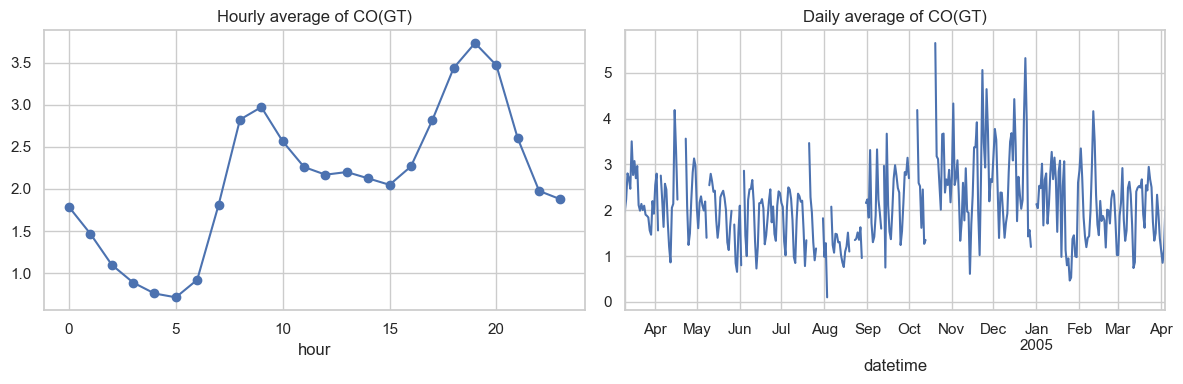

In [17]:
if pollutant_cols:
    pcol = pollutant_cols[0]
    hourly = df.groupby("hour")[pcol].mean()
    daily = df.set_index("datetime").resample("D")[pcol].mean()

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    hourly.plot(ax=axes[0], marker="o", title=f"Hourly average of {pcol}")
    daily.plot(ax=axes[1], title=f"Daily average of {pcol}")
    plt.tight_layout()
else:
    print("No pollutant columns detected for hourly/daily plots.")

## Skewness & Kurtosis (Pollutants)


In [19]:
sk_df = pd.DataFrame({
    "skew": df[num_cols].skew(),
    "kurtosis": df[num_cols].kurt()
}).sort_values("skew", ascending=False)

display(sk_df.head(12))

,skew,kurtosis
NOx(GT),1.715781,3.402134
NMHC(GT),1.557017,2.270289
CO(GT),1.369753,2.667779
C6H6(GT),1.361532,2.488706
PT08.S3(NOx),1.101729,2.677559
PT08.S1(CO),0.755907,0.335129
PT08.S5(O3),0.627864,0.078612
NO2(GT),0.621714,0.465032
PT08.S2(NMHC),0.561566,0.063244
T,0.309357,-0.456274


## Suggest log1p transformations (only for non-negative features)


In [20]:
high_skew = [c for c in sk_df.index if sk_df.loc[c, "skew"] > 1.0 and (df[c] >= 0).all()]
print("Highly skewed non-negative features (consider log1p):", high_skew)


Highly skewed non-negative features (consider log1p): []


## Explicit Non-Linearity: Scatter + Polynomial Fit


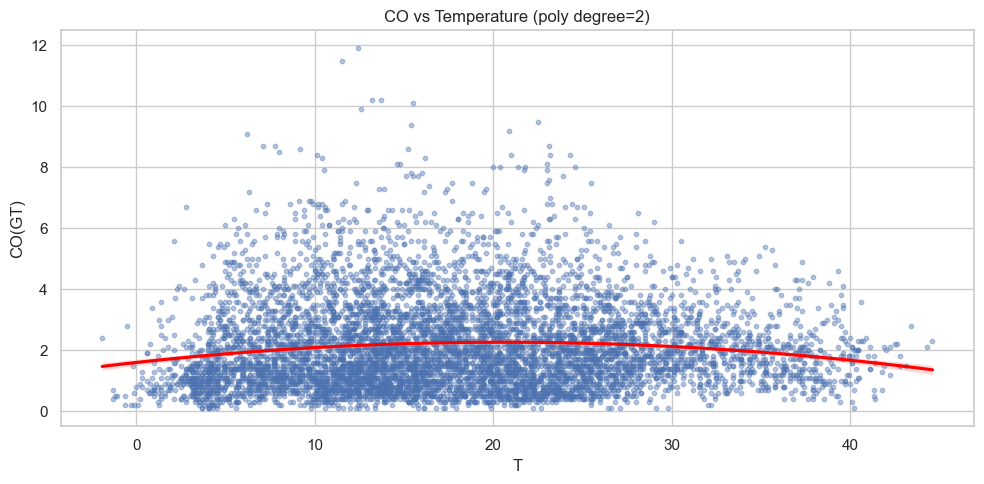

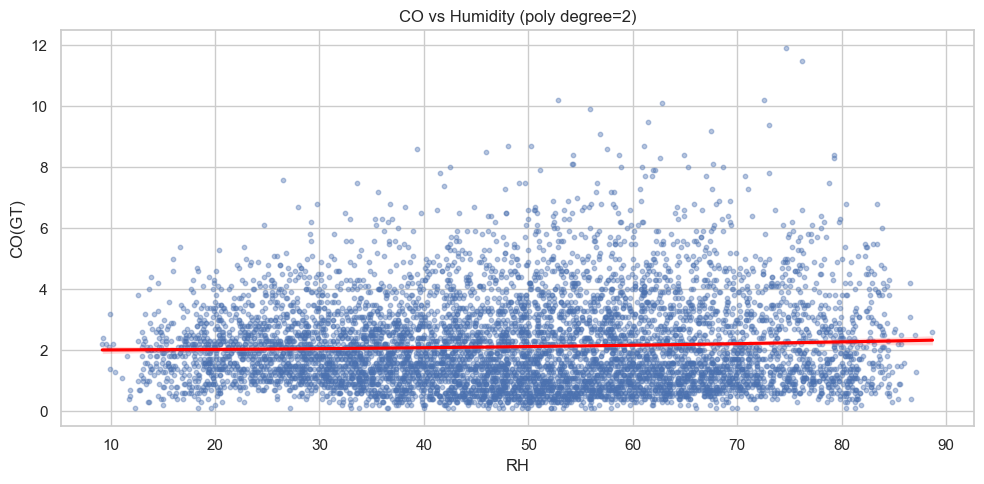

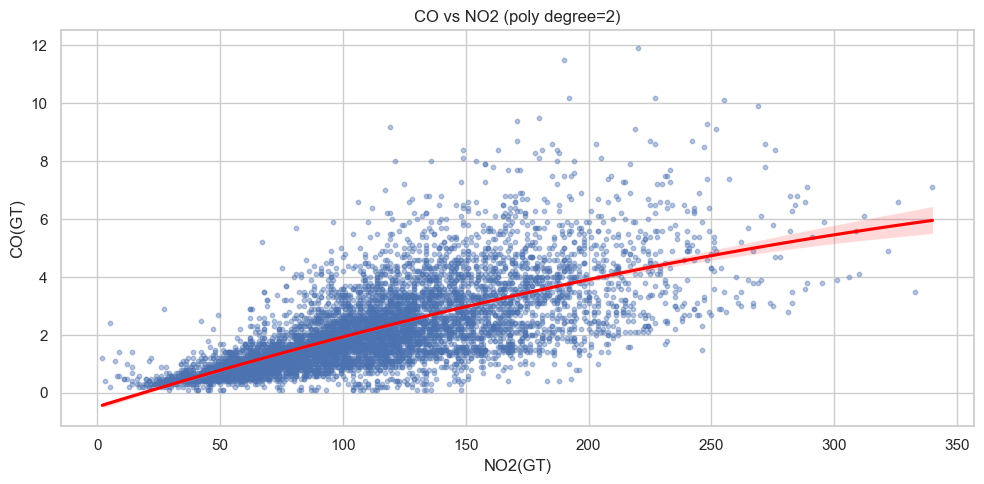

In [21]:
co_col = next((c for c in pollutant_cols if "CO" in c), None)
no2_col = next((c for c in pollutant_cols if "NO2" in c), None)
temp_col = next((c for c in df.columns if c == "T" or "Temp" in c or "Temperature" in c), None)
hum_col = next((c for c in df.columns if c == "RH" or "Humidity" in c), None)

pairs = [
    (temp_col, co_col, "CO vs Temperature"),
    (hum_col, co_col, "CO vs Humidity"),
    (no2_col, co_col, "CO vs NO2")
]
for x, y, title in pairs:
    if x and y and x in df.columns and y in df.columns:
        sns.regplot(data=df, x=x, y=y, order=2,
                    scatter_kws={"s": 10, "alpha": 0.4},
                    line_kws={"color": "red"})
        plt.title(f"{title} (poly degree=2)")
        plt.tight_layout()
        plt.show()

## EDA Insight Summary


## Top missing columns


In [22]:
top_missing = mv[mv["missing"] > 0].sort_values("missing_pct", ascending=False).head(5)


## Hourly variation for CO


In [23]:
if co_col:
    hourly_stats = df.groupby("hour")[co_col].agg(["mean", "std"]).round(2)
else:
    hourly_stats = None

print("Key Findings from EDA:")
print("- Missingness concentrated in:", list(top_missing.index))
if co_col:
    print(f"- {co_col} hourly mean range: [{hourly_stats['mean'].min():.2f}, {hourly_stats['mean'].max():.2f}]")
if temp_col and co_col:
    r = df[[temp_col, co_col]].dropna().corr(method="spearman").iloc[0, 1]
    print(f"- Temperature–CO Spearman corr: {r:.2f} (curvature suggests non-linearity)")
if hum_col and co_col:
    r = df[[hum_col, co_col]].dropna().corr(method="spearman").iloc[0, 1]
    print(f"- Humidity–CO Spearman corr: {r:.2f}")
if no2_col and co_col:
    r = df[[no2_col, co_col]].dropna().corr(method="spearman").iloc[0, 1]
    print(f"- NO2–CO Spearman corr: {r:.2f}")
print(f"- Skewed features (skew > 1): {high_skew} -> consider log1p before modeling.")


Key Findings from EDA:
- Missingness concentrated in: ['NMHC(GT)', 'CO(GT)', 'NO2(GT)', 'NOx(GT)', 'PT08.S5(O3)']
- CO(GT) hourly mean range: [0.71, 3.73]
- Temperature–CO Spearman corr: 0.07 (curvature suggests non-linearity)
- Humidity–CO Spearman corr: -0.01
- NO2–CO Spearman corr: 0.73
- Skewed features (skew > 1): [] -> consider log1p before modeling.


## Save Cleaned Dataset for Modeling


In [24]:
out_path = Path("AirQualityUCI_clean.csv")
df.to_csv(out_path, index=False)
print(f"Saved cleaned dataset to: {out_path.resolve()}")

Saved cleaned dataset to: /Users/satvikaakati/Desktop/Applied Analytics/air+quality/AirQualityUCI_clean.csv
